Dataset Shape: (284807, 31)
Target Column: Class

Missing Values Before Cleaning:
0

Missing Target Values:
0

Training Shape: (227845, 30)
Testing Shape : (56962, 30)

Before SMOTE:
Class
0    227451
1       394
Name: count, dtype: int64

After SMOTE:
Class
0    227451
1    227451
Name: count, dtype: int64

LOGISTIC REGRESSION
Precision : 0.0579
Recall    : 0.9184
ROC-AUC   : 0.971

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962


Confusion Matrix:
[[55399  1465]
 [    8    90]]

RANDOM FOREST
Precision : 0.871
Recall    : 0.8265
ROC-AUC   : 0.9782

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
         

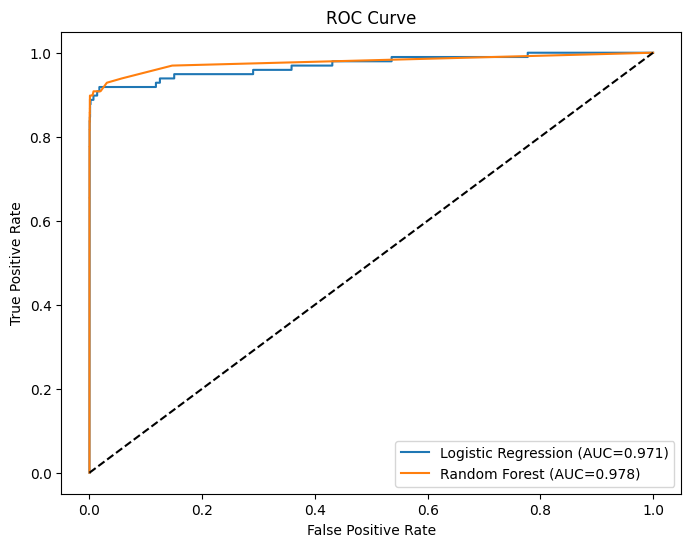


Best Model:
Model        Random Forest
Precision         0.870968
Recall            0.826531
ROC-AUC           0.978241
Name: 1, dtype: object


In [ ]:
# ==========================================
# FRAUD DETECTION PIPELINE
# ==========================================

# Install (run once in Colab)
# !pip install imbalanced-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve
)

from imblearn.over_sampling import SMOTE

# ==========================================
# LOAD DATA
# ==========================================

df = pd.read_csv("/content/creditcard.csv")

print("Dataset Shape:", df.shape)

# ==========================================
# CLEAN COLUMN NAMES
# ==========================================

df.columns = df.columns.str.strip()

# Detect target column
target_col = None

for col in df.columns:
    if col.lower() == "class":
        target_col = col
        break

if target_col is None:
    raise ValueError("Target column 'Class' not found.")

print("Target Column:", target_col)

# ==========================================
# HANDLE MISSING VALUES
# ==========================================

print("\nMissing Values Before Cleaning:")
print(df.isnull().sum().sum())

# Remove rows where target is missing
df = df.dropna(subset=[target_col])

# Convert target to integer
df[target_col] = df[target_col].astype(int)

print("\nMissing Target Values:")
print(df[target_col].isnull().sum())

# ==========================================
# FEATURES & TARGET
# ==========================================

X = df.drop(columns=[target_col])
y = df[target_col]

# ==========================================
# HANDLE MISSING FEATURE VALUES
# ==========================================

imputer = SimpleImputer(strategy="median")
X = imputer.fit_transform(X)

# ==========================================
# SCALE FEATURES
# ==========================================

scaler = StandardScaler()
X = scaler.fit_transform(X)

# ==========================================
# TRAIN TEST SPLIT
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining Shape:", X_train.shape)
print("Testing Shape :", X_test.shape)

# ==========================================
# APPLY SMOTE
# ==========================================

print("\nBefore SMOTE:")
print(y_train.value_counts())

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print("\nAfter SMOTE:")
print(pd.Series(y_train_smote).value_counts())

# ==========================================
# LOGISTIC REGRESSION
# ==========================================




LOGISTIC REGRESSION
Precision : 0.0579
Recall    : 0.9184
ROC-AUC   : 0.971

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962


Confusion Matrix:
[[55399  1465]
 [    8    90]]

RANDOM FOREST
Precision : 0.871
Recall    : 0.8265
ROC-AUC   : 0.9782

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.87      0.83      0.85        98

    accuracy                           1.00     56962
   macro avg       0.94      0.91      0.92     56962
weighted avg       1.00      1.00      1.00     56962


Confusion Matrix:
[[56852    12]
 [   17    81]]

MODEL COMPARISON
                 Model  Precisio

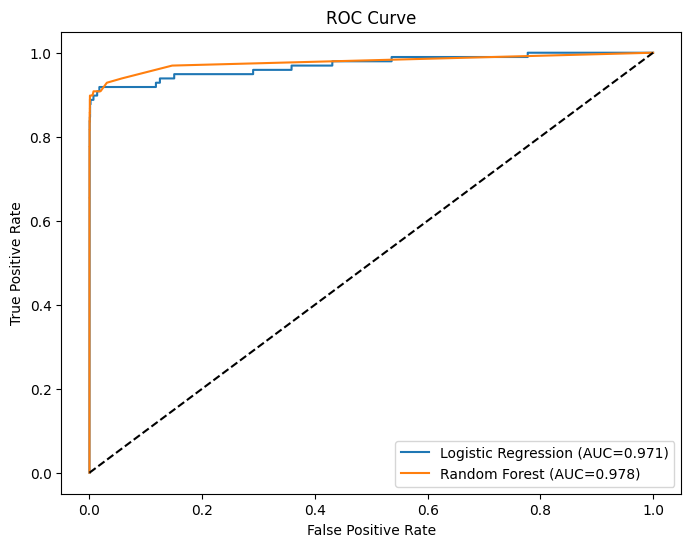


Best Model:
Model        Random Forest
Precision         0.870968
Recall            0.826531
ROC-AUC           0.978241
Name: 1, dtype: object


In [ ]:
lr_precision, lr_recall, lr_auc = evaluate_model(
    "LOGISTIC REGRESSION",
    y_test,
    lr_pred,
    lr_prob
)

rf_precision, rf_recall, rf_auc = evaluate_model(
    "RANDOM FOREST",
    y_test,
    rf_pred,
    rf_prob
)

# ==========================================
# COMPARISON TABLE
# ==========================================

results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Precision": [lr_precision, rf_precision],
    "Recall": [lr_recall, rf_recall],
    "ROC-AUC": [lr_auc, rf_auc]
})

print("\nMODEL COMPARISON")
print(results)

# ==========================================
# ROC CURVE
# ==========================================

lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_prob)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)

plt.figure(figsize=(8, 6))

plt.plot(
    lr_fpr,
    lr_tpr,
    label=f"Logistic Regression (AUC={lr_auc:.3f})"
)

plt.plot(
    rf_fpr,
    rf_tpr,
    label=f"Random Forest (AUC={rf_auc:.3f})"
)

plt.plot([0, 1], [0, 1], "k--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# ==========================================
# BEST MODEL
# ==========================================

best_model = results.sort_values(
    by="ROC-AUC",
    ascending=False
)

print("\nBest Model:")
print(best_model.iloc[0])